# Practical Application III: Comparing Classifiers

**Overview**: In this practical application, your goal is to compare the performance of the classifiers we encountered in this section, namely K Nearest Neighbor, Logistic Regression, Decision Trees, and Support Vector Machines.  We will utilize a dataset related to marketing bank products over the telephone.  



### Getting Started

Our dataset comes from the UCI Machine Learning repository [link](https://archive.ics.uci.edu/ml/datasets/bank+marketing).  The data is from a Portugese banking institution and is a collection of the results of multiple marketing campaigns.  We will make use of the article accompanying the dataset [here](CRISP-DM-BANK.pdf) for more information on the data and features.



### Problem 1: Understanding the Data

To gain a better understanding of the data, please read the information provided in the UCI link above, and examine the **Materials and Methods** section of the paper.  How many marketing campaigns does this data represent?

Data represents **17 campaigns**

### Problem 2: Read in the Data

Use pandas to read in the dataset `bank-additional-full.csv` and assign to a meaningful variable name.

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('data/bank-additional-full.csv', sep = ';')

In [3]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

### Problem 3: Understanding the Features


Examine the data description below, and determine if any of the features are missing values or need to be coerced to a different data type.


```
Input variables:
# bank client data:
1 - age (numeric)
2 - job : type of job (categorical: 'admin.','blue-collar','entrepreneur','housemaid','management','retired','self-employed','services','student','technician','unemployed','unknown')
3 - marital : marital status (categorical: 'divorced','married','single','unknown'; note: 'divorced' means divorced or widowed)
4 - education (categorical: 'basic.4y','basic.6y','basic.9y','high.school','illiterate','professional.course','university.degree','unknown')
5 - default: has credit in default? (categorical: 'no','yes','unknown')
6 - housing: has housing loan? (categorical: 'no','yes','unknown')
7 - loan: has personal loan? (categorical: 'no','yes','unknown')
# related with the last contact of the current campaign:
8 - contact: contact communication type (categorical: 'cellular','telephone')
9 - month: last contact month of year (categorical: 'jan', 'feb', 'mar', ..., 'nov', 'dec')
10 - day_of_week: last contact day of the week (categorical: 'mon','tue','wed','thu','fri')
11 - duration: last contact duration, in seconds (numeric). Important note: this attribute highly affects the output target (e.g., if duration=0 then y='no'). Yet, the duration is not known before a call is performed. Also, after the end of the call y is obviously known. Thus, this input should only be included for benchmark purposes and should be discarded if the intention is to have a realistic predictive model.
# other attributes:
12 - campaign: number of contacts performed during this campaign and for this client (numeric, includes last contact)
13 - pdays: number of days that passed by after the client was last contacted from a previous campaign (numeric; 999 means client was not previously contacted)
14 - previous: number of contacts performed before this campaign and for this client (numeric)
15 - poutcome: outcome of the previous marketing campaign (categorical: 'failure','nonexistent','success')
# social and economic context attributes
16 - emp.var.rate: employment variation rate - quarterly indicator (numeric)
17 - cons.price.idx: consumer price index - monthly indicator (numeric)
18 - cons.conf.idx: consumer confidence index - monthly indicator (numeric)
19 - euribor3m: euribor 3 month rate - daily indicator (numeric)
20 - nr.employed: number of employees - quarterly indicator (numeric)

Output variable (desired target):
21 - y - has the client subscribed a term deposit? (binary: 'yes','no')
```



In [135]:
# explore columns to understand the breakdown of values, towards identifying any missing data (like 'unknown' values)
# also columns which do not provide much information

columns = df.select_dtypes(include='object').columns
for column in columns:
    print(f'****** {column} ******')
    print(df[column].value_counts(normalize=True))

****** job ******
job
admin.           0.253035
blue-collar      0.224677
technician       0.163713
services         0.096363
management       0.070992
retired          0.041760
entrepreneur     0.035350
self-employed    0.034500
housemaid        0.025736
unemployed       0.024619
student          0.021244
unknown          0.008012
Name: proportion, dtype: float64
****** marital ******
marital
married     0.605225
single      0.280859
divorced    0.111974
unknown     0.001942
Name: proportion, dtype: float64
****** education ******
education
university.degree      0.295426
high.school            0.231014
basic.9y               0.146766
professional.course    0.127294
basic.4y               0.101389
basic.6y               0.055647
unknown                0.042027
illiterate             0.000437
Name: proportion, dtype: float64
****** default ******
default
no         0.791201
unknown    0.208726
yes        0.000073
Name: proportion, dtype: float64
****** housing ******
housing
yes       

### Problem 4: Understanding the Task

After examining the description and data, your goal now is to clearly state the *Business Objective* of the task.  State the objective below.

***Business objective*** of this task is to find the best model that can explain the success of the bank marketing campaigns and the attributes that lead to the campaign's success

### Problem 5: Engineering Features

Now that you understand your business objective, we will build a basic model to get started.  Before we can do this, we must work to encode the data.  Using just the bank information features, prepare the features and target column for modeling with appropriate encoding and transformations.

***Data Preparation 1***

Dropping following 2 columns:
1. **duration**
   : as it is mainly used for benchmarking purposes and there is specific guideline saying this attribute should not be used outside of this context
3. **poutcome**
   : previous outcome. Dropping this mainly because it is not providing a lot of information as more than 86% of the information is nonexistant. The breakdown of the different values for this attribute is below:

        nonexistent    0.863431
        failure        0.103234
        success        0.033335

In [6]:
df_bank = df.drop(['duration', 'poutcome'], axis=1)
df_bank.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,1,999,0,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,1,999,0,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,1,999,0,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,1,999,0,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,1,999,0,1.1,93.994,-36.4,4.857,5191.0,no


In [7]:
df_bank.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 19 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  campaign        41188 non-null  int64  
 11  pdays           41188 non-null  int64  
 12  previous        41188 non-null  int64  
 13  emp.var.rate    41188 non-null  float64
 14  cons.price.idx  41188 non-null  float64
 15  cons.conf.idx   41188 non-null  float64
 16  euribor3m       41188 non-null  float64
 17  nr.employed     41188 non-null 

***Data Prepration 2*** 

There are unknown values for each of the attributes which do not provide any information. Additionally, the proportion of these rows are comparatively quite small. Drop the rows which have 'unknown' values for 'job' and 'marital' columns. There is added advantage with this as some of these columns will become binary resuting in complexity (fewer features)

In [8]:
df_bank_clean = df_bank.loc[(df['job'] != 'unknown') &
                            (df['marital'] != 'unknown') &
                            (df['housing'] != 'unknown') &
                            (df['loan'] != 'unknown')] 

df_bank_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 39803 entries, 0 to 41187
Data columns (total 19 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             39803 non-null  int64  
 1   job             39803 non-null  object 
 2   marital         39803 non-null  object 
 3   education       39803 non-null  object 
 4   default         39803 non-null  object 
 5   housing         39803 non-null  object 
 6   loan            39803 non-null  object 
 7   contact         39803 non-null  object 
 8   month           39803 non-null  object 
 9   day_of_week     39803 non-null  object 
 10  campaign        39803 non-null  int64  
 11  pdays           39803 non-null  int64  
 12  previous        39803 non-null  int64  
 13  emp.var.rate    39803 non-null  float64
 14  cons.price.idx  39803 non-null  float64
 15  cons.conf.idx   39803 non-null  float64
 16  euribor3m       39803 non-null  float64
 17  nr.employed     39803 non-null  floa

In [9]:
df_bank_clean['default'].value_counts()

default
no         31587
unknown     8213
yes            3
Name: count, dtype: int64

***Data Preparation 3***

map unknown values in default to 'no' with assumption that defaulted accounts are important and would definitely be recorded as 'yes'. This is a corner case as the number of 'yes' values is quite small (0.000075). Perhaps a candidate to drop this column


In [10]:
df_bank_clean = df_bank_clean.copy()
df_bank_clean['default'] = df_bank_clean['default'].map(lambda x: 'no' if x == 'unknown' else x)

In [11]:
df_bank_clean['default'].value_counts(normalize=True)

default
no     0.999925
yes    0.000075
Name: proportion, dtype: float64

In [12]:
df_bank_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 39803 entries, 0 to 41187
Data columns (total 19 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             39803 non-null  int64  
 1   job             39803 non-null  object 
 2   marital         39803 non-null  object 
 3   education       39803 non-null  object 
 4   default         39803 non-null  object 
 5   housing         39803 non-null  object 
 6   loan            39803 non-null  object 
 7   contact         39803 non-null  object 
 8   month           39803 non-null  object 
 9   day_of_week     39803 non-null  object 
 10  campaign        39803 non-null  int64  
 11  pdays           39803 non-null  int64  
 12  previous        39803 non-null  int64  
 13  emp.var.rate    39803 non-null  float64
 14  cons.price.idx  39803 non-null  float64
 15  cons.conf.idx   39803 non-null  float64
 16  euribor3m       39803 non-null  float64
 17  nr.employed     39803 non-null  floa

**Data Transormation**

Transform the data. Use OrdinaEncoder for the education column as there is ineherent ordering and use OneHotEncoder for the rest
Also fix the column names after transformation to make them more readable

In [13]:
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, StandardScaler
from sklearn.compose import make_column_transformer

In [14]:
# Transform the data. Use OrdinaEncoder for the education column as there is ineherent ordering and use OneHotEncoder for the rest
# Also fix the column names after transformation to make them more readable

education_order = [
    'illiterate',
    'basic.4y',
    'basic.6y',
    'basic.9y',
    'unknown',
    'high.school',
    'professional.course',
    'university.degree'
]

transformer = make_column_transformer((OneHotEncoder(drop='if_binary', sparse_output=False), 
                                       ['job', 
                                        'marital', 
                                        'default', 
                                        'housing', 
                                        'loan', 
                                        'contact', 
                                        'month', 
                                        'day_of_week',
                                        'y']),
                               (OrdinalEncoder(categories=[education_order]), ['education']),
                                remainder='passthrough')

t_data = transformer.fit_transform(df_bank_clean)
feature_names = [feature.split('__')[1] for feature in transformer.get_feature_names_out()]
df_bank_clean = pd.DataFrame(t_data, columns=feature_names)



In [15]:
df_bank_clean.rename(columns={'y_yes':'y'}, inplace=True)

In [125]:
#check columns and column names after transformation

df_bank_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39803 entries, 0 to 39802
Data columns (total 44 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   job_admin.         39803 non-null  float64
 1   job_blue-collar    39803 non-null  float64
 2   job_entrepreneur   39803 non-null  float64
 3   job_housemaid      39803 non-null  float64
 4   job_management     39803 non-null  float64
 5   job_retired        39803 non-null  float64
 6   job_self-employed  39803 non-null  float64
 7   job_services       39803 non-null  float64
 8   job_student        39803 non-null  float64
 9   job_technician     39803 non-null  float64
 10  job_unemployed     39803 non-null  float64
 11  marital_divorced   39803 non-null  float64
 12  marital_married    39803 non-null  float64
 13  marital_single     39803 non-null  float64
 14  default_yes        39803 non-null  float64
 15  housing_yes        39803 non-null  float64
 16  loan_yes           398

In [126]:
# find proportions of successful campaigns to set the baseline for our classifiers during evaluation

df_bank_clean['y'].value_counts(normalize=True)

y
0.0    0.88727
1.0    0.11273
Name: proportion, dtype: float64

### Problem 6: Train/Test Split

With your data prepared, split it into a train and test set.

In [18]:
from sklearn.model_selection import train_test_split

In [19]:
X, y = df_bank_clean.drop('y', axis=1), df_bank_clean['y']
X.head()

,job_admin.,job_blue-collar,job_entrepreneur,job_housemaid,job_management,job_retired,job_self-employed,job_services,job_student,job_technician,...,education,age,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,56.0,1.0,999.0,0.0,1.1,93.994,-36.4,4.857,5191.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,5.0,57.0,1.0,999.0,0.0,1.1,93.994,-36.4,4.857,5191.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,5.0,37.0,1.0,999.0,0.0,1.1,93.994,-36.4,4.857,5191.0
3,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,2.0,40.0,1.0,999.0,0.0,1.1,93.994,-36.4,4.857,5191.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,5.0,56.0,1.0,999.0,0.0,1.1,93.994,-36.4,4.857,5191.0


In [20]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, stratify=y)
X_train = X_train.values
X_test = X_test.values
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((26668, 43), (26668,), (13135, 43), (13135,))

### Problem 7: A Baseline Model

Before we build our first model, we want to establish a baseline.  What is the baseline performance that our classifier should aim to beat?

***Baseline***

Use the basic majority class proportion as baseline, i.e. if we randomly guess the class based on the proportion of the classes, we would get 87% success. So the trained classifier models should beat at least this baseline which is ~88%

normalized value_counts of y column:
    
    no     0.88727
    yes    0.11273
    

### Problem 8: A Simple Model

Use Logistic Regression to build a basic model on your data.  

In [21]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

from time import time

In [22]:
lr_pipe = Pipeline([('scaler', StandardScaler()),
                    ('lr', LogisticRegression())])
lr_start_time = time()
lr_pipe.fit(X_train, y_train)
lr_end_time = time()
lr_train_time = lr_end_time - lr_start_time

### Problem 9: Score the Model

What is the accuracy of your model?

In [23]:
lr_train_accuracy = lr_pipe.score(X_train, y_train)
lr_test_accuracy = lr_pipe.score(X_test, y_test)
lr_train_time, lr_train_accuracy, lr_test_accuracy

(0.0904390811920166, 0.8988675566221689, 0.9022459078797107)

Test accuracy of the basic logistic model is 0.902

### Problem 10: Model Comparisons

Now, we aim to compare the performance of the Logistic Regression model to our KNN algorithm, Decision Tree, and SVM models.  Using the default settings for each of the models, fit and score each.  Also, be sure to compare the fit time of each of the models.  Present your findings in a `DataFrame` similar to that below:

| Model | Train Time | Train Accuracy | Test Accuracy |
| ----- | ---------- | -------------  | -----------   |
|     |    |.     |.     |

In [24]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

In [25]:
classifiers = [LogisticRegression(), KNeighborsClassifier(), DecisionTreeClassifier(), SVC()]
model = ['LogisticRegression', 'KNearestNeighbors', 'DecisionTree', 'SVM']
train_time = []
train_accuracy = []
test_accuracy = []

for classifier in classifiers:
    pipe = Pipeline([('scaler', StandardScaler()), 
                    ('classifier', classifier)])
    start_time = time()
    pipe.fit(X_train, y_train)
    end_time = time()
    train_time.append(end_time - start_time)
    train_accuracy.append(pipe.score(X_train, y_train))
    test_accuracy.append(pipe.score(X_test, y_test))

train_time, train_accuracy, test_accuracy

([0.20640206336975098,
  0.004664182662963867,
  0.09177088737487793,
  12.100297927856445],
 [0.8988675566221689,
  0.9110169491525424,
  0.9954252287385631,
  0.9086920653967302],
 [0.9022459078797107,
  0.8929577464788733,
  0.8398934145413018,
  0.8995051389417587])

In [26]:
model_df = pd.DataFrame({'Model': model,
                         'Train Time': train_time,
                         'Train Accuracy': train_accuracy,
                         'Test Accuracy': test_accuracy})
#model_df = model_df.set_index('Model')
model_df

,Model,Train Time,Train Accuracy,Test Accuracy
0,LogisticRegression,0.206402,0.898868,0.902246
1,KNearestNeighbors,0.004664,0.911017,0.892958
2,DecisionTree,0.091771,0.995425,0.839893
3,SVM,12.100298,0.908692,0.899505


### Problem 11: Improving the Model

Now that we have some basic models on the board, we want to try to improve these.  Below, we list a few things to explore in this pursuit.


- Hyperparameter tuning and grid search.  All of our models have additional hyperparameters to tune and explore.  For example the number of neighbors in KNN or the maximum depth of a Decision Tree.  
- Adjust your performance metric

**Note**

In addition to accuracy we will also track ROC-AUC and precision-recall as other metrics to evaluate the models. For the classifiers it is important to look at the FPR and TPR to see how effective the models are

In [64]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.metrics import roc_auc_score, RocCurveDisplay, PrecisionRecallDisplay, average_precision_score
import matplotlib.pyplot as plt
import numpy as np

In [28]:
def DisplayRocAndPrecisionRecallCurve(estimator, estimator_name):
    plt.figure(figsize=(8,6))
    fig, ax = plt.subplots(1, 2)
    RocCurveDisplay.from_estimator(estimator, X_test, y_test, ax=ax[0])
    ax[0].set_title(f' ROC for {estimator_name}')
    ax[0].set_xlabel('FPR')
    ax[0].set_ylabel('TPR')

    PrecisionRecallDisplay.from_estimator(estimator, X_test, y_test, ax=ax[1])
    ax[1].set_title(f'Precision Recall for {estimator_name}')
    ax[1].set_xlabel('Recall')
    ax[1].set_ylabel('Precision')

    plt.tight_layout()
    plt.show()

In [29]:
# grid search across 'penalty' and 'C' values for logistic regression
lgr_params = {'lgr__penalty': ['l1', 'l2'],
              'lgr__solver': ['liblinear'],
              'lgr__C': [0.001, 0.01, 0.1]}
              

In [30]:
lgr_pipe = Pipeline([('scaler', StandardScaler()),
                     ('lgr', LogisticRegression(random_state=42, max_iter=10_000))])
lgr_grid = GridSearchCV(lgr_pipe, param_grid=lgr_params, cv=5)
lgr_grid_start_time = time()
lgr_grid.fit(X_train, y_train)
lgr_grid_end_time = time()

In [65]:
lgr_grid_train_time = lgr_grid_end_time - lgr_grid_start_time
lgr_grid_train_accuracy = lgr_grid.best_estimator_.score(X_train, y_train)
lgr_grid_test_accuracy = lgr_grid.best_estimator_.score(X_test, y_test)
lgr_grid_roc_auc = float(roc_auc_score(y_test, lgr_grid.best_estimator_.predict_proba(X_test)[:, 1]))
lgr_grid_ap = float(average_precision_score(y_test, lgr_grid.best_estimator_.predict_proba(X_test)[:, 1]))

print(lgr_grid.best_params_)
lgr_grid_train_time, lgr_grid_train_accuracy, lgr_grid_test_accuracy, lgr_grid_roc_auc, lgr_grid_ap

{'lgr__C': 0.01, 'lgr__penalty': 'l2', 'lgr__solver': 'liblinear'}


(3.6383891105651855,
 0.898567571621419,
 0.9022459078797107,
 0.7860096373178156,
 0.456493458875834)

<Figure size 800x600 with 0 Axes>

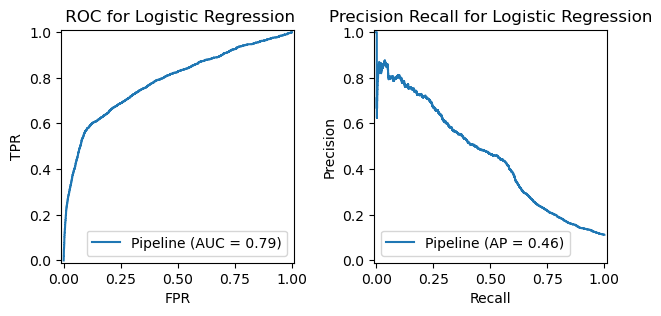

In [32]:
DisplayRocAndPrecisionRecallCurve(lgr_grid.best_estimator_, 'Logistic Regression')

In [33]:
#Decision Tree Classifier

dtree_params = {
         'dtree__max_depth': range(2,11),
         'dtree__min_samples_split': [2, 4, 6],
         'dtree__criterion': ['gini', 'entropy', 'log_loss'],
         'dtree__min_samples_leaf': [1, 2, 3]
         }

In [34]:
dtree_pipe = Pipeline([('scaler', StandardScaler()), 
                       ('dtree', DecisionTreeClassifier())])
dtree_grid = GridSearchCV(dtree_pipe, param_grid=dtree_params, cv=5)
dtree_start_time = time()
dtree_grid.fit(X_train, y_train)
dtree_end_time = time()

In [70]:
dtree_grid_train_time = dtree_end_time - dtree_start_time
dtree_grid_train_accuracy = dtree_grid.best_estimator_.score(X_train, y_train)
dtree_grid_test_accuracy = dtree_grid.best_estimator_.score(X_test, y_test)
dtree_grid_roc_auc = float(roc_auc_score(y_test, dtree_grid.best_estimator_.predict_proba(X_test)[:, 1]))
dtree_grid_ap = float(average_precision_score(y_test, dtree_grid.best_estimator_.predict_proba(X_test)[:, 1]))

print(dtree_grid.best_params_)
dtree_grid_train_time, dtree_grid_train_accuracy, dtree_grid_test_accuracy, dtree_grid_roc_auc, dtree_grid_ap

{'dtree__criterion': 'gini', 'dtree__max_depth': 3, 'dtree__min_samples_leaf': 1, 'dtree__min_samples_split': 2}


(36.89562273025513,
 0.8993175341232938,
 0.9009516558812334,
 0.7538079734760545,
 0.38556564881937616)

<Figure size 800x600 with 0 Axes>

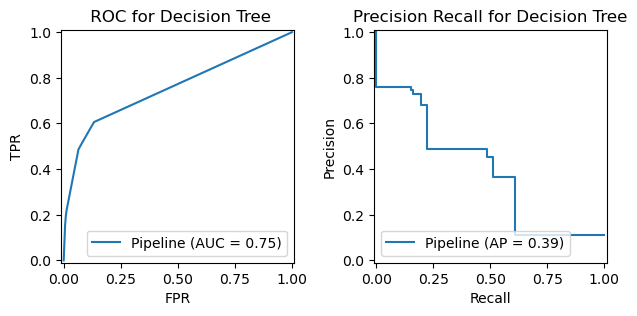

In [36]:
DisplayRocAndPrecisionRecallCurve(dtree_grid.best_estimator_, 'Decision Tree')

In [37]:
# nearest neighbor classifier

knn_params = {'knn__n_neighbors': list(range(1,30,2))}

In [38]:
knn_pipe = Pipeline([('scaler', StandardScaler()), 
                       ('knn', KNeighborsClassifier())])
knn_grid = GridSearchCV(knn_pipe, param_grid=knn_params, cv=5)
knn_start_time = time()
knn_grid.fit(X_train, y_train)
knn_end_time = time()

In [71]:
knn_grid_train_time = knn_end_time - knn_start_time
knn_grid_train_accuracy = knn_grid.best_estimator_.score(X_train, y_train)
knn_grid_test_accuracy = knn_grid.best_estimator_.score(X_test, y_test)
knn_grid_roc_auc = float(roc_auc_score(y_test, knn_grid.best_estimator_.predict_proba(X_test)[:,1]))
knn_grid_ap = float(average_precision_score(y_test, knn_grid.best_estimator_.predict_proba(X_test)[:, 1]))

print(knn_grid.best_params_)
knn_grid_train_time, knn_grid_train_accuracy, knn_grid_test_accuracy, knn_grid_roc_auc, knn_grid_ap

{'knn__n_neighbors': 29}


(5.760976076126099,
 0.8998050097495125,
 0.898515416825276,
 0.7611962496872751,
 0.4071477961992686)

<Figure size 800x600 with 0 Axes>

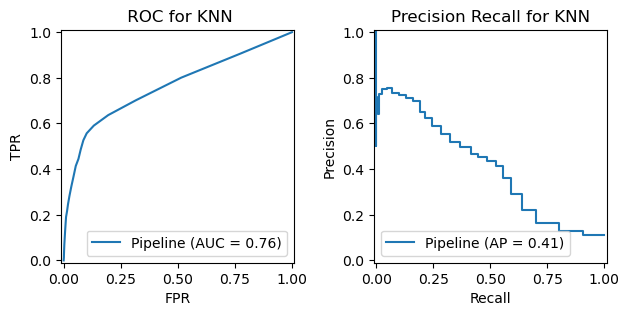

In [40]:
DisplayRocAndPrecisionRecallCurve(knn_grid.best_estimator_, 'KNN')

In [128]:
# svm with gaussian kernel
svm_rbf_params = {'svc__kernel': ['rbf'],
              'svc__C': [0.001, 0.01, 0.1, 1, 10]}
#              ['linear', 'poly', 'rbf', 'sigmoid']}

In [42]:
svm_rbf_pipe = Pipeline([('scaler', StandardScaler()), 
                       ('svc', SVC(probability=True))])
svm_rbf_grid = GridSearchCV(svm_rbf_pipe, param_grid=svm_rbf_params, cv=5)
svm_rbf_start_time = time()
svm_rbf_grid.fit(X_train, y_train)
svm_rbf_end_time = time()

In [72]:
svm_rbf_grid_train_time = svm_rbf_end_time - svm_rbf_start_time
svm_rbf_grid_train_accuracy = svm_rbf_grid.best_estimator_.score(X_train, y_train)
svm_rbf_grid_test_accuracy = svm_rbf_grid.best_estimator_.score(X_test, y_test)
svm_rbf_grid_roc_auc = float((roc_auc_score(y_test, svm_rbf_grid.best_estimator_.predict_proba(X_test)[:,1])))
svm_rbf_grid_ap = float(average_precision_score(y_test, svm_rbf_grid.best_estimator_.predict_proba(X_test)[:, 1]))

print(svm_rbf_grid.best_params_)
svm_rbf_grid_train_time, svm_rbf_grid_train_accuracy, svm_rbf_grid_test_accuracy, svm_rbf_grid_roc_auc, svm_rbf_grid_ap

{'svc__C': 1, 'svc__kernel': 'rbf'}


(728.2130491733551,
 0.9086920653967302,
 0.8995051389417587,
 0.7158400896800813,
 0.41071112632370027)

<Figure size 800x600 with 0 Axes>

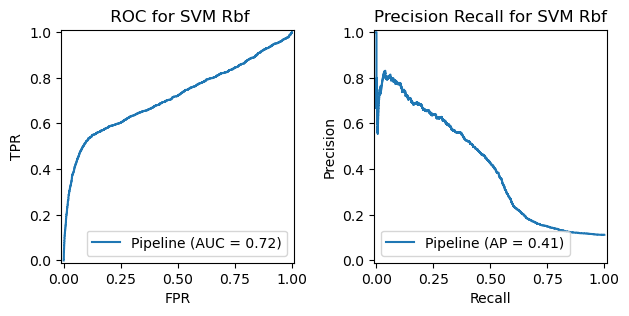

In [44]:
DisplayRocAndPrecisionRecallCurve(svm_rbf_grid.best_estimator_, 'SVM Rbf')

In [127]:
# svm with polynomial kernel
svm_poly_params = {'svc__kernel': ['poly'],
              'svc__degree': [2, 3]}

In [46]:
svm_poly_pipe = Pipeline([('scaler', StandardScaler()), 
                       ('svc', SVC(probability=True))])
svm_poly_grid = GridSearchCV(svm_poly_pipe, param_grid=svm_poly_params, cv=5)
svm_poly_start_time = time()
svm_poly_grid.fit(X_train, y_train)
svm_poly_end_time = time()

In [73]:
svm_poly_grid_train_time = svm_poly_end_time - svm_poly_start_time
svm_poly_grid_train_accuracy = svm_poly_grid.best_estimator_.score(X_train, y_train)
svm_poly_grid_test_accuracy = svm_poly_grid.best_estimator_.score(X_test, y_test)
svm_poly_grid_roc_auc = float((roc_auc_score(y_test, svm_poly_grid.best_estimator_.predict_proba(X_test)[:,1])))
svm_poly_grid_ap = float(average_precision_score(y_test, svm_poly_grid.best_estimator_.predict_proba(X_test)[:, 1]))

print(svm_poly_grid.best_params_)
svm_poly_grid_train_time, svm_poly_grid_train_accuracy, svm_poly_grid_test_accuracy, svm_poly_grid_roc_auc, svm_poly_grid_ap

{'svc__degree': 2, 'svc__kernel': 'poly'}


(359.73628973960876,
 0.9011174441277936,
 0.9002664636467453,
 0.6951194160412071,
 0.4062805843972593)

<Figure size 800x600 with 0 Axes>

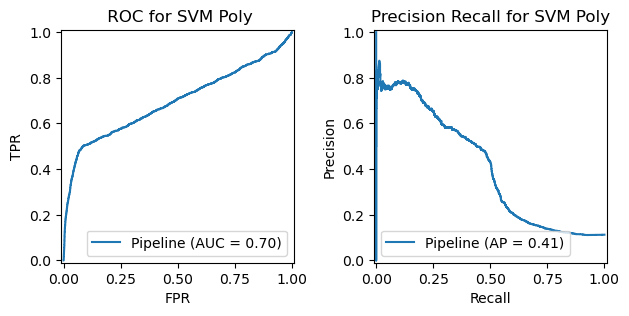

In [48]:
DisplayRocAndPrecisionRecallCurve(svm_poly_grid.best_estimator_, 'SVM Poly')

**Visualize results to compare models**

1. Visualize to compare test/train accuracies, roc-auc and average precision scores
2. Times for the best models of each classifer
3. Visualize ROC-AUC and precision recall curves


In [80]:
train_accuracy = [lgr_grid_train_accuracy, 
                  dtree_grid_train_accuracy, 
                  knn_grid_train_accuracy, 
                  svm_rbf_grid_train_accuracy,
                  svm_poly_grid_train_accuracy]

test_accuracy = [lgr_grid_test_accuracy, 
                 dtree_grid_test_accuracy, 
                 knn_grid_test_accuracy, 
                 svm_rbf_grid_test_accuracy,
                 svm_poly_grid_test_accuracy]

train_time = [lgr_grid_train_time, 
              dtree_grid_train_time, 
              knn_grid_train_time, 
              svm_rbf_grid_train_time,
              svm_poly_grid_train_time]

roc_auc = [lgr_grid_roc_auc, 
           dtree_grid_roc_auc, 
           knn_grid_roc_auc, 
           svm_rbf_grid_roc_auc,
           svm_poly_grid_roc_auc]

a_p = [lgr_grid_ap,
      dtree_grid_ap,
      knn_grid_ap,
      svm_rbf_grid_ap,
      svm_poly_grid_ap]

classifiers = ['Logistic Regression', 'Decision Tree', 'KNN', 'SVM Rbf', 'SVM Poly']

In [129]:
# common routine to annotate the value on top of each bar in the bar graphs
# row and column are the co-ordinates of the subplot

def annotate_bars(bars, values, row, column):
   for i, bar in enumerate(bars):
    height = round(values[i], 3)
    ax[row, column].text(
        bar.get_x() + bar.get_width() / 2, 
        height,                           
        f'{height}',                      
        ha='center',                      
        va='bottom',                      
        fontsize=16,                      
        color='black'                 
    ) 

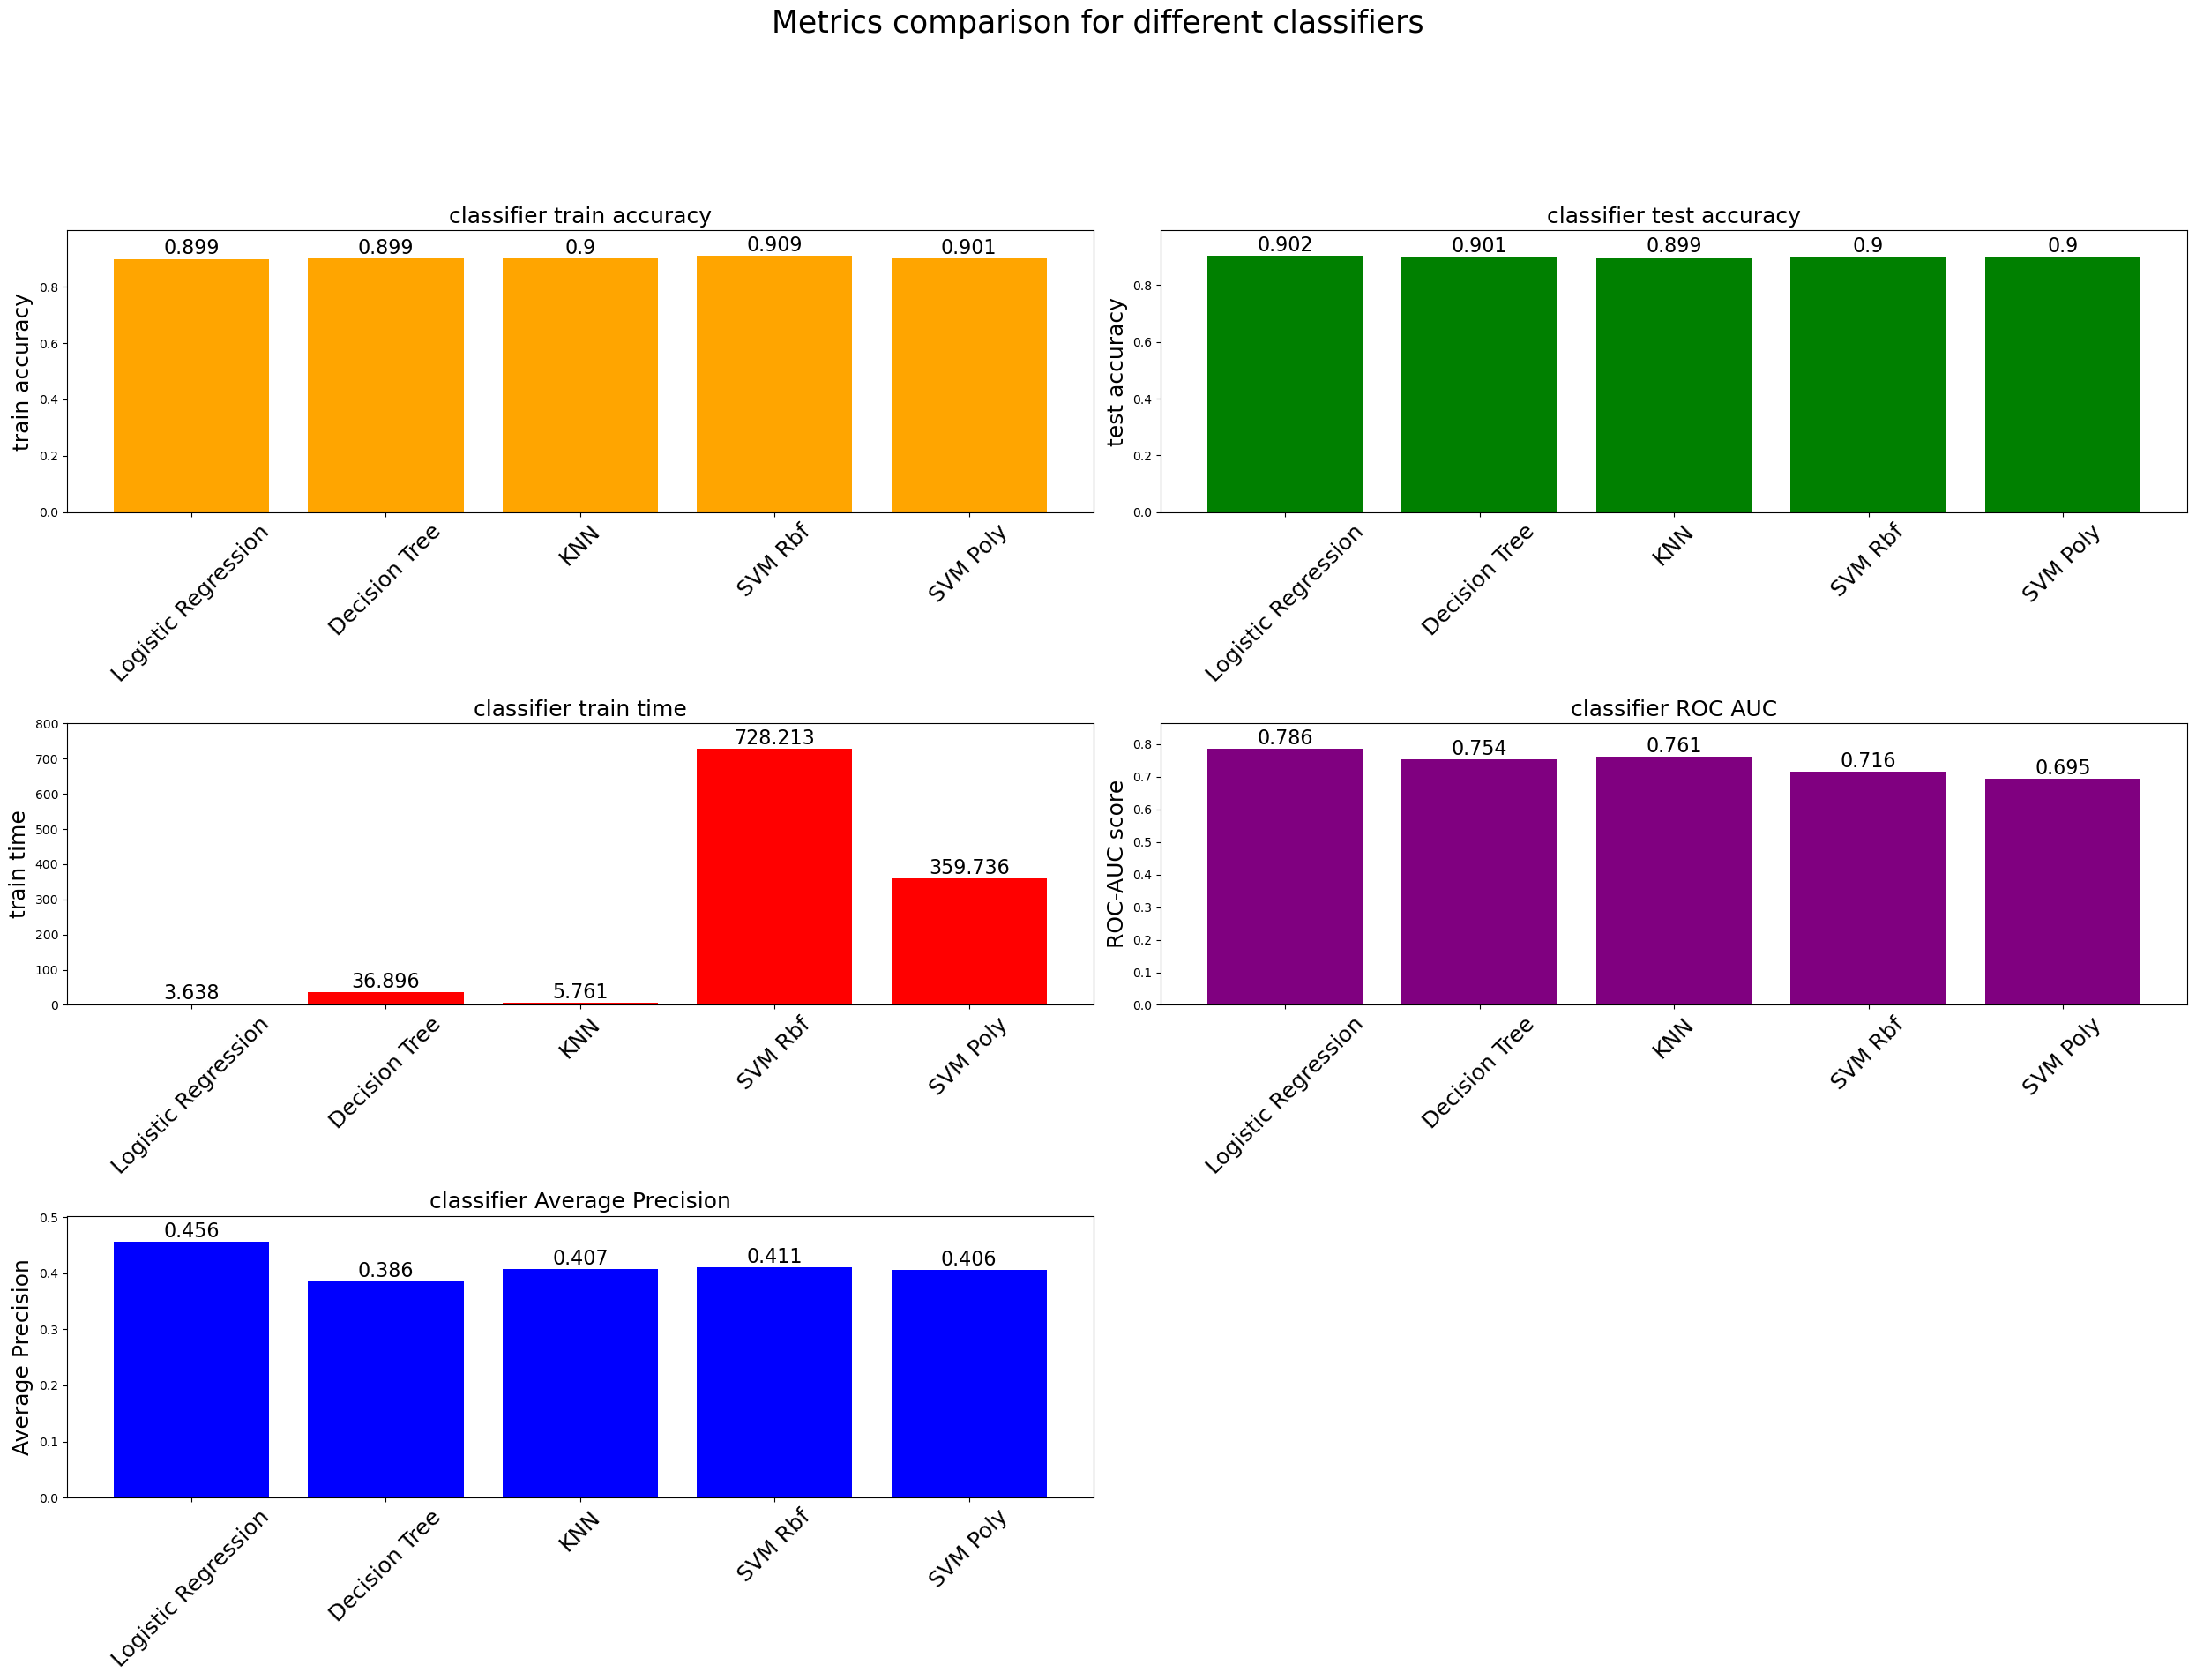

In [130]:
# Compare train and test accuracies, roc-auc scores and average precision scores

fig, ax = plt.subplots(3, 2, figsize=(25, 20))
fig.suptitle('Metrics comparison for different classifiers', fontsize=25)

bars = ax[0,0].bar(classifiers, train_accuracy, color='orange')
annotate_bars(bars, train_accuracy, 0, 0)
ax[0,0].set_xticks(range(len(classifiers)))
ax[0,0].set_xticklabels(classifiers, rotation=45, fontsize=18)
ax[0,0].set_ylabel('train accuracy', fontsize=18)
ax[0,0].set_title('classifier train accuracy', fontsize=18)
ax[0,0].set_ylim(0, max(train_accuracy) * 1.1)

# Fixed: Changed train_accuracy to test_accuracy for the height parameter
bars = ax[0,1].bar(classifiers, test_accuracy, color='green')  # FIXED: Using test_accuracy instead of train_accuracy
annotate_bars(bars, test_accuracy, 0, 1)
ax[0,1].set_xticks(range(len(classifiers)))
ax[0,1].set_xticklabels(classifiers, rotation=45, fontsize=18)
ax[0,1].set_ylabel('test accuracy', fontsize=18)
ax[0,1].set_title('classifier test accuracy', fontsize=18)
ax[0,1].set_ylim(0, max(test_accuracy) * 1.1)


bars = ax[1,0].bar(classifiers, train_time, color='red')
annotate_bars(bars, train_time, 1, 0)
ax[1,0].set_xticks(range(len(classifiers)))
ax[1,0].set_xticklabels(classifiers, rotation=45, fontsize=18)
ax[1,0].set_ylabel('train time', fontsize=18)
ax[1,0].set_title('classifier train time', fontsize=18)
ax[1,0].set_ylim(0, max(train_time) * 1.1)

bars = ax[1,1].bar(classifiers, roc_auc, color='purple')
annotate_bars(bars, roc_auc, 1, 1)
ax[1,1].set_xticks(range(len(classifiers)))
ax[1,1].set_xticklabels(classifiers, rotation=45, fontsize=18)
ax[1,1].set_ylabel('ROC-AUC score', fontsize=18)
ax[1,1].set_title('classifier ROC AUC', fontsize=18)
ax[1,1].set_ylim(0, max(roc_auc) * 1.1)

bars = ax[2,0].bar(classifiers, a_p, color='blue')
annotate_bars(bars, a_p, 2, 0)
ax[2,0].set_xticks(range(len(classifiers)))
ax[2,0].set_xticklabels(classifiers, rotation=45, fontsize=18)
ax[2,0].set_ylabel('Average Precision', fontsize=18)
ax[2,0].set_title('classifier Average Precision', fontsize=18)
ax[2,0].set_ylim(0, max(a_p) * 1.1)

ax[2,1].axis('off')

plt.tight_layout(rect=[0,0.03, 1, 0.9])
plt.show()


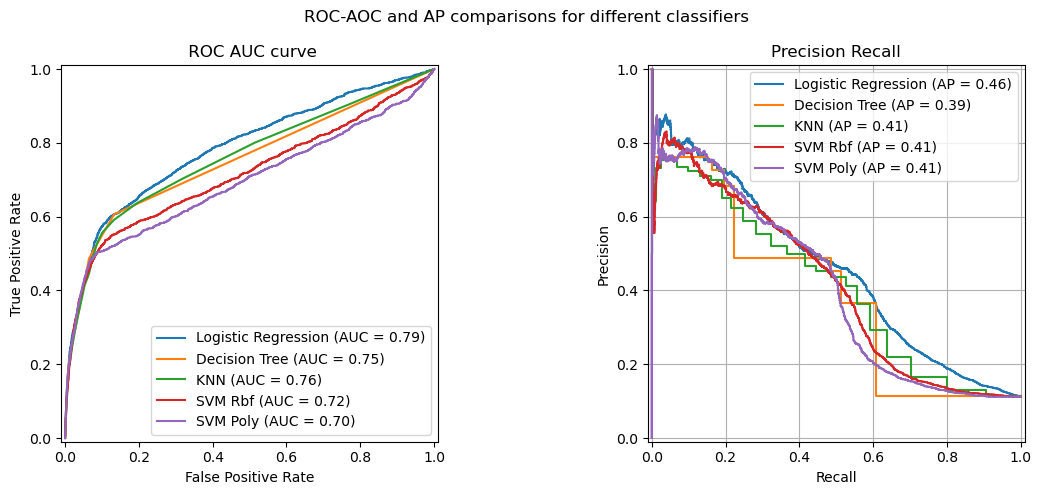

In [132]:
# create visualization to compare all classifiers' roc-auc and Precision Recall curves

fig, ax = plt.subplots(1, 2, figsize=(12,5))
fig.suptitle('ROC-AOC and AP comparisons for different classifiers')

RocCurveDisplay.from_estimator(lgr_grid.best_estimator_, X_test, y_test, ax=ax[0], name='Logistic Regression')
RocCurveDisplay.from_estimator(dtree_grid.best_estimator_, X_test, y_test, ax=ax[0], name='Decision Tree')
RocCurveDisplay.from_estimator(knn_grid.best_estimator_, X_test, y_test, ax=ax[0], name='KNN')
RocCurveDisplay.from_estimator(svm_rbf_grid.best_estimator_, X_test, y_test, ax=ax[0], name='SVM Rbf')
RocCurveDisplay.from_estimator(svm_poly_grid.best_estimator_, X_test, y_test, ax=ax[0], name = 'SVM Poly')

ax[0].set_title(f' ROC AUC curve')
ax[0].set_xlabel('False Positive Rate')
ax[0].set_ylabel('True Positive Rate')


PrecisionRecallDisplay.from_estimator(lgr_grid.best_estimator_, X_test, y_test, ax=ax[1], name='Logistic Regression')
PrecisionRecallDisplay.from_estimator(dtree_grid.best_estimator_, X_test, y_test, ax=ax[1], name='Decision Tree')
PrecisionRecallDisplay.from_estimator(knn_grid.best_estimator_, X_test, y_test, ax=ax[1], name='KNN')
PrecisionRecallDisplay.from_estimator(svm_rbf_grid.best_estimator_, X_test, y_test, ax=ax[1], name='SVM Rbf')
PrecisionRecallDisplay.from_estimator(svm_poly_grid.best_estimator_, X_test, y_test, ax=ax[1], name='SVM Poly')

ax[1].set_title(f'Precision Recall')
ax[1].set_xlabel('Recall')
ax[1].set_ylabel('Precision')

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [134]:
# visualize the results as a dataframe, identify the best classifier for different metrics towards doing model evaluation

results_df = pd.DataFrame({'classifier': classifiers,
                           'train_time': train_time,
                          'train_accuracy': train_accuracy,
                          'test_accuracy': test_accuracy,
                          'roc_auc_score': roc_auc,
                           'average precision': a_p})
results_df = results_df.set_index('classifier')

print(f'Classifier with best train time: {classifiers[train_time.index(min(train_time))]}')
print(f'Classifier with best train accuracy: {classifiers[train_accuracy.index(max(train_accuracy))]}')
print(f'Classifier with best test accuracy: {classifiers[test_accuracy.index(max(test_accuracy))]}')
print(f'Classifier with best roc_auc score: {classifiers[roc_auc.index(max(roc_auc))]}')
print(f'Classifier with best average precision score: {classifiers[a_p.index(max(a_p))]}')
print()

results_df.head(len(classifiers))

Classifier with best train time: Logistic Regression
Classifier with best train accuracy: SVM Rbf
Classifier with best test accuracy: Logistic Regression
Classifier with best roc_auc score: Logistic Regression
Classifier with best average precision score: Logistic Regression



,train_time,train_accuracy,test_accuracy,roc_auc_score,average precision
classifier,,,,,
Logistic Regression,3.638389,0.898568,0.902246,0.786010,0.456493
Decision Tree,36.895623,0.899318,0.900952,0.753808,0.385566
KNN,5.760976,0.899805,0.898515,0.761196,0.407148
SVM Rbf,728.213049,0.908692,0.899505,0.715840,0.410711
SVM Poly,359.736290,0.901117,0.900266,0.695119,0.406281


**Model evaluation**
-

**Summary**
-
___________

Based on all metrics, Logistic Regression model with hyper parameters: {'lgr__C': 0.01, 'lgr__penalty': 'l2', 'lgr__solver': 'liblinear'} is the best model for this classification problem.

Following table summarizes the metrics for the classifiers with the best metric in bold

| Classifier      | training time | training accuracy     | test accuracy | roc_auc score | average precision score |
| :---        |    :----:   |    :----:   |    :----:   |    :----:   |          ---: |
| Logistic Regression      | **3.638389**  | 898568   | **0.902246** | **0.786010** | **0.456493** |
| Decision Tree   | 36.895623 |	0.899318 |	0.900952 |	0.753808 |	0.385566 |
| K Nearest Neighbor | 5.760976 |	0.899805 |	0.898515 |	0.761196 |	0.407148 |
| SVM gaussian | 728.213049	| **0.908692**	| 0.899505	| 0.715840	| 0.410711
| SVM linear | 359.736290 |	0.901117 |	0.900266 |	0.695119 |	0.406281 |

**Details**
-
___________

***Overall note***

The accuracies, both training and test did not vary much between the classifiers. Other important metrics like roc-auc score and average precision score led to a clear difference in performance. Additionally, train time for training this model was a fraction of the others which was an added benefit

**LogisticRegression**: As mentioned above logistic regression performed best in most of the metrics. It performed the best in all metrics except the training accuracy metric. The parameter grid searched over following:

    lgr_params = {'lgr__penalty': ['l1', 'l2'],
                  'lgr__solver': ['liblinear'],
                  'lgr__C': [0.001, 0.01, 0.1]}

**Decision Tree** 

Did a grid search was done over the following:

    dtree_params = {
             'dtree__max_depth': range(2,11),
             'dtree__min_samples_split': [2, 4, 6],
             'dtree__criterion': ['gini', 'entropy', 'log_loss'],
             'dtree__min_samples_leaf': [1, 2, 3]
             }
As is clear from the table, well and its scores were close to the Logistic Regression though some metrics like average precision was much lower, in fact the minimum of all the classifiers

**K Nearest Neighbor**

Did a grid search over following hyper parameters:

    knn_params = {'knn__n_neighbors': list(range(1,30,2))}

From the table below, it is clear that this classifier performed well in most metrics did not perform as well as Logistic Regression in any metric

**Support Vector with rbf (gaussian) kernel**

Did a grid search over following hyper parameters:

    svm_rbf_params = {'svc__kernel': ['rbf'],
                  'svc__C': [0.001, 0.01, 0.1, 1, 10]}

Took a long time to train (longest among all classifiers) over this grid but did not find a model better than the Logistic Regression with respect to any of the metrics except training accuracy by a very small margin

**Support Vector with polynomial kernel**

Did a grid search with following hyper parameters:

    svm_poly_params = {'svc__kernel': ['poly'],
                  'svc__degree': [2, 3]}

Took long time to train (2nd longest) over this grid and did not find a model that performed better than Logistic Regression in any of the metrics.

*Note*: tried doing a grid search with all kernels to find the best kernel and different hyperparameters. Took too much time did not complete even after running for more than 20 hours. Abandoned that approach and selectively analyzed rbf and linear kernels with different hyper parameters




**Explore feature impact** on results for the best model

In [106]:
from sklearn.inspection import permutation_importance

In [108]:
r_lgr = permutation_importance(lgr_grid.best_estimator_, X_test, y_test,
                           n_repeats=30,
                           random_state=0)

for i in r_lgr.importances_mean.argsort()[::-1]:
    if r_lgr.importances_mean[i] - 2 * r_lgr.importances_std[i] > 0:
        print(f"{X.columns[i]:<30}"
              f"{r_lgr.importances_mean[i]:.4f}"
              f" +/- {r_lgr.importances_std[i]:.4f}")

pdays                         0.0140 +/- 0.0007
nr.employed                   0.0070 +/- 0.0008
cons.price.idx                0.0045 +/- 0.0006
emp.var.rate                  0.0040 +/- 0.0007
contact_telephone             0.0016 +/- 0.0003
euribor3m                     0.0014 +/- 0.0004
previous                      0.0010 +/- 0.0002
month_jul                     0.0010 +/- 0.0003
month_mar                     0.0008 +/- 0.0003
job_retired                   0.0007 +/- 0.0002
month_oct                     0.0002 +/- 0.0001


In [124]:
lgr_df = pd.DataFrame({'Attribute': X.columns, 
                       'abs coef': abs(lgr_grid.best_estimator_.named_steps['lgr'].coef_[0]),
                       'coef': lgr_grid.best_estimator_.named_steps['lgr'].coef_[0]})
lgr_df.head(43)
lgr_df = lgr_df.set_index('Attribute')
lgr_df = lgr_df.sort_values(by='abs coef', ascending=False)
lgr_df.head(20)


,abs coef,coef
Attribute,,
emp.var.rate,0.399263,-0.399263
nr.employed,0.351863,-0.351863
pdays,0.316111,-0.316111
cons.price.idx,0.234802,0.234802
contact_telephone,0.209675,-0.209675
month_may,0.199374,-0.199374
previous,0.130433,-0.130433
month_mar,0.122238,0.122238
euribor3m,0.121382,-0.121382


In [121]:
lgr_df_positive = lgr_df.loc[lgr_df['coef'] > 0]
lgr_df_positive = lgr_df_positive.sort_values(by='abs coef', ascending=False)
lgr_df_negative = lgr_df.loc[lgr_df['coef'] <= 0]
lgr_df_negative = lgr_df_negative.sort_values(by='abs coef', ascending=False)

lgr_df_positive[['coef']].head(10)

,coef
Attribute,
cons.price.idx,0.234802
month_mar,0.122238
month_jul,0.114091
cons.conf.idx,0.113319
month_jun,0.078263
job_retired,0.057039
job_student,0.051980
day_of_week_wed,0.035643
month_apr,0.031898


In [123]:
lgr_df_negative[['coef']].head(10)

,coef
Attribute,
emp.var.rate,-0.399263
nr.employed,-0.351863
pdays,-0.316111
contact_telephone,-0.209675
month_may,-0.199374
previous,-0.130433
euribor3m,-0.121382
campaign,-0.088812
day_of_week_mon,-0.078171


In [139]:
lgr_df_positive[['coef']].head(40)

,coef
Attribute,
cons.price.idx,0.234802
month_mar,0.122238
month_jul,0.114091
cons.conf.idx,0.113319
month_jun,0.078263
job_retired,0.057039
job_student,0.051980
day_of_week_wed,0.035643
month_apr,0.031898


In [140]:
lgr_df_negative[['coef']].head(40)

,coef
Attribute,
emp.var.rate,-0.399263
nr.employed,-0.351863
pdays,-0.316111
contact_telephone,-0.209675
month_may,-0.199374
previous,-0.130433
euribor3m,-0.121382
campaign,-0.088812
day_of_week_mon,-0.078171


Findings and Recommendations
-


Summary
-

The success of direct bank marketing campains was **most sensitive** to the following attributes (in the order of decreasing impact):



| Attribute name  | Description     |
| :---        |    ----:   | 
| **pdays** | number of days that passed by after the client was last contacted from a previous campaign |
| **nr.employed** | number of employees - quarterly indicator (numeric)|
|**cons.price.idx** | consumer price index - monthly indicator (numeric)|
| **emp.var.rate** | employment variation rate - quarterly indicator (numeric) |
| **contact_telephone** | contact communication type (categorical: 'cellular','telephone') |
| **euribor3m** | euribor 3 month rate - daily indicator (numeric) |
| **previous** | number of contacts performed before this campaign and for this client (numeric) |
| **month_jul**| last contact month of year was July |
| **month_mar**| last contact month of year was March |
| **job_retired** | people who are retired |
| **month_oct** | last contact month of year was October |

_____

**Top 10 attributes** that had the most **postive** impact on the success of campaigns, meaning put effort to create conditions/actions increase these metrics (order of decreasing impact):



| Attribute name  | Description     |
| :---        |    ----:   | 
| **cons.price.idx**|  consumer price index - monthly indicator (numeric)| 
| **month_mar**|  	last contact month of year was March (categorical: 'jan', 'feb', 'mar', ..., 'nov', 'dec')| 
| **month_jul**| 	last contact month of year was July (categorical: 'jan', 'feb', 'mar', ..., 'nov', 'dec')| 
| **cons.conf.idx**|  consumer confidence index - monthly indicator (numeric)| 
| **month_jun**|  last contact month of year was June (categorical: 'jan', 'feb', 'mar', ..., 'nov', 'dec')| 
| **job_retired**|  people who are retired| 
| **job_student**| people who are students| 
| **day_of_week_wed**|  last contact day of the week was Wednesday| 
| **month_apr**| last contact month of year was April | 
| **job_admin.**|  people who have admin jobs | 


___

**Top 10 attributes** that had most **negative** impact on the success of the campaigns, meaning put effort to create conditions/take actions to decrease these metrics (order of decreasing impact):



| Attribute name  | Description     |
| :---        |    ----:   | 
| **emp.var.rate**|  employment variation rate - quarterly indicator (numeric)| 
| **nr.employed**|  number of employees - quarterly indicator (numeric)| 
| **pdays**| number of days that passed by after the client was last contacted from a previous campaign | 
| **contact_telephone**| communicated over telephone (instead of cellular)| 
| **month_may** | last contact was May| 
| **previous**| number of contacts performed before this campaign and for this client (numeric)| 
| **euribor3m**|  euribor 3 month rate - daily indicator (numeric)| 
| **campaign**| number of contacts performed during this campaign and for this client (numeric, includes last contact)| 
| **day_of_week_mon**| last contact day of the week was Monday| 
| **job_blue-collar**|  blue collar job| 

___

Details
-



In addition to the top 10 attributes, the following **attributes** also led to **positive** results in the campaign (in decreasing order of impact)

**education**: Higher education led to more success

**month_aug****: More calls in month of August were successful

**day_of_week_thu**: Calling on thursdays led to more successful calls

**month_dec**: calling in the month of december led to more successful calls

**marital_single**: campain was more successful with single people

**loan_yes**: campaign was more successful with people who had loans

**month_oct**: campaigns were more successful in the month of octoer

**job_management**: campaigns were more successful with people in management jobs

**day_of_week_tue**: campaigns were more successful when contacted on Tuesdays and Fridays

**job_entrepreneur**: campaigns were more successful with entrepreneurs

**age**: campaigns were more successful with people with higher age

**job_technician**: campaigns were more successful with people in technician jobs

**job_unemployed**: campaigns were successful with unemployed

**marital_married**: campaigns were more successful with married people

___

In addition to the top 10 negative attributes, the following **attributes** led to **negative impact** on the outcome of the campaign (in decreasing order of impact) :

**month_nov**: calling in the month of december led to fewer successful calls

**marital_divorced**: campaigns were less successful with divorced people

**job_services**: campaigns were less successful with people in services industry 

**job_housemaid**: campaigns were less successful with housemaids

**housing_yes**: campaigns were less successful with people how had housing

**job_self-employed**: campaigns were less successful with people who were self-employed

**default_yes**: campaigns were less successful with people who had defaulted

**month_sep**: campaigns were less successful in the month of september


### Future work

Identified the following work for future:

1. The grid search for the models done was very basic. Do some more research (especially with sigmoid and linear kernels of svm to find a better model)
2. SVM model training takes too long. Research any public literature on how to speed this up
3. Was expecting Decision Trees to do better than how it performed. Research more on how to optimize this model to do better
4. In the recommendation section, it would be good to find the actual numbers to help the banks. For example, would be good to know how the campaigns performed with a particular age group